# 02 — Exploratory Data Analysis

## About

**Purpose:** Explore the labelled provider dataset to identify which features predict exclusion risk.<br>
**Author:** Ganapathy K<br>
**Date:** 2026-05-15<br>
**Notes:** Operates on the 500,000-row labelled sample produced by 01. Findings feed feature selection in 03_modelling.<br>
**Description:** Loads the labelled dataset, profiles nulls and dtypes, drops sparse columns (>30% null), and analyses exclusion rate by entity type, state, and provider taxonomy. Decodes taxonomy codes via the NUCC reference and ranks feature importance with a RandomForest baseline. Outputs a feature-candidate shortlist for the modelling notebook.

### Change Control

| Date       | Version | Author      | Changes         |
|------------|---------|-------------|-----------------|
| 2026-05-15 | 1.0     | Ganapathy K | Initial version |

In [1]:
%load_ext autoreload
%autoreload 2

## 1. Setup
### 1.1 Imports

In [2]:
import logging
from datetime import datetime
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

### 1.2 Configure logging

In [3]:
log_folder = Path("logs")
log_folder.mkdir(exist_ok=True)
log_filename = log_folder / f"run_{datetime.now().strftime('%Y-%m-%d')}.log"

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    handlers=[
        logging.FileHandler(log_filename, encoding='utf-8'),
        logging.StreamHandler(),
    ],
    force=True,
)
logger = logging.getLogger(__name__)

### 1.3 Config

In [4]:
processed_file_path = Path("D:/Data Science/Visual Studio Code/healthcare-provider-termination/data/processed/labelled_dataset.parquet")

## 2. Load Data

In [5]:
providers_raw_df = pd.read_parquet(processed_file_path)
providers_df = providers_raw_df.copy()
logger.info(f"Loaded labelled dataset — shape: {providers_df.shape}")

2026-05-17 02:32:31,015 | INFO | Loaded labelled dataset — shape: (500000, 331)


## 3. Data Quality
### 3.1 Target Distribution

In [6]:
# Target variable distribution
print(providers_df['excluded'].value_counts())
print(providers_df['excluded'].value_counts(normalize=True) * 100)

excluded
0    498817
1      1183
Name: count, dtype: int64
excluded
0    99.7634
1     0.2366
Name: proportion, dtype: float64


### 3.2 Null Analysis

In [7]:
# Null value treatment
null_percentages = (providers_df.isna().mean() * 100).sort_values(ascending=False)
print(null_percentages[null_percentages > 0])

NPI Deactivation Reason Code                                                  100.0000
Other Provider Identifier Issuer_49                                           100.0000
Other Provider Identifier_50                                                  100.0000
Other Provider Identifier Issuer_50                                           100.0000
Other Provider Identifier Type Code_50                                        100.0000
                                                                                ...   
Last Update Date                                                                8.5192
Provider Business Practice Location Address Postal Code                         8.5192
Provider Business Practice Location Address Country Code (If outside U.S.)      8.5192
Healthcare Provider Taxonomy Code_1                                             8.5192
Healthcare Provider Primary Taxonomy Switch_1                                   8.5192
Length: 329, dtype: float64


### 3.3 Drop Sparse Columns

In [8]:
# Drop columns with >30% nulls
columns_to_drop = null_percentages[null_percentages > 30].index
providers_df = providers_df.drop(columns=columns_to_drop)
logger.info(f"Columns before: 331 | dropped: {len(columns_to_drop)} | after: {providers_df.shape[1]}")

2026-05-17 02:32:32,434 | INFO | Columns before: 331 | dropped: 305 | after: 26


### 3.4 Surviving Columns

In [9]:
# Columns surviving the 30% null threshold
print(providers_df.columns.tolist())

['NPI', 'Entity Type Code', 'Provider Last Name (Legal Name)', 'Provider First Name', 'Provider Credential Text', 'Provider First Line Business Mailing Address', 'Provider Business Mailing Address City Name', 'Provider Business Mailing Address State Name', 'Provider Business Mailing Address Postal Code', 'Provider Business Mailing Address Country Code (If outside U.S.)', 'Provider Business Mailing Address Telephone Number', 'Provider First Line Business Practice Location Address', 'Provider Business Practice Location Address City Name', 'Provider Business Practice Location Address State Name', 'Provider Business Practice Location Address Postal Code', 'Provider Business Practice Location Address Country Code (If outside U.S.)', 'Provider Business Practice Location Address Telephone Number', 'Provider Enumeration Date', 'Last Update Date', 'Provider Sex Code', 'Healthcare Provider Taxonomy Code_1', 'Provider License Number_1', 'Provider License Number State Code_1', 'Healthcare Provider

### 3.5 Dtypes

In [10]:
# Data types and non-null counts across surviving columns
print(providers_df.dtypes)

NPI                                                                             int64
Entity Type Code                                                              float64
Provider Last Name (Legal Name)                                                object
Provider First Name                                                            object
Provider Credential Text                                                       object
Provider First Line Business Mailing Address                                   object
Provider Business Mailing Address City Name                                    object
Provider Business Mailing Address State Name                                   object
Provider Business Mailing Address Postal Code                                  object
Provider Business Mailing Address Country Code (If outside U.S.)               object
Provider Business Mailing Address Telephone Number                            float64
Provider First Line Business Practice Location Address

## 4. Exclusion Rate Analysis
### 4.1 By Entity Type

In [11]:
# Entity type distribution (1 = individual, 2 = organisation)
print(providers_df['Entity Type Code'].value_counts())

# Exclusion rate by entity type
print(providers_df.groupby('Entity Type Code')['excluded'].mean() * 100)

Entity Type Code
1.0    389023
2.0     68381
Name: count, dtype: int64
Entity Type Code
1.0    0.254227
2.0    0.049721
Name: excluded, dtype: float64


### 4.2 By State

In [12]:
# Exclusion rate by state (top 15)
state_exclusion_rate = providers_df.groupby('Provider Business Mailing Address State Name')['excluded'].mean() * 100
print(state_exclusion_rate.sort_values(ascending=False).head(15))

Provider Business Mailing Address State Name
KY    0.550696
ND    0.462250
WV    0.408302
PR    0.393245
WY    0.380711
CA    0.372548
AL    0.367985
MO    0.323480
MI    0.309005
OR    0.287162
OH    0.286825
NY    0.286624
ID    0.286041
NM    0.283789
FL    0.269892
Name: excluded, dtype: float64


### 4.3 By Taxonomy

In [13]:
# Taxonomy exclusion rate with counts (top 15 by exclusion rate)
taxonomy_summary = providers_df.groupby('Healthcare Provider Taxonomy Code_1').agg(
    total=('excluded', 'count'),
    exclusion_rate=('excluded', 'mean')
)
taxonomy_summary['exclusion_rate'] = taxonomy_summary['exclusion_rate'] * 100
print(taxonomy_summary.sort_values('exclusion_rate', ascending=False).head(15))

                                     total  exclusion_rate
Healthcare Provider Taxonomy Code_1                       
174M00000X                               2       50.000000
163WC1600X                               4       25.000000
106S00000X                               5       20.000000
175T00000X                               6       16.666667
171WH0202X                               6       16.666667
213EP0504X                               6       16.666667
202C00000X                              11        9.090909
207LA0401X                              29        6.896552
207ZI0100X                              16        6.250000
2471M1202X                              26        3.846154
204C00000X                             179        2.793296
103TA0700X                              36        2.777778
237700000X                              73        2.739726
208VP0000X                             257        2.723735
207QA0401X                             122        2.4590

### 4.4 By Taxonomy (min 100 providers)

In [14]:
# Taxonomy exclusion rate — minimum 100 providers (reliable rates only)
print(taxonomy_summary[taxonomy_summary['total'] >= 100].sort_values('exclusion_rate', ascending=False).head(15))

                                     total  exclusion_rate
Healthcare Provider Taxonomy Code_1                       
204C00000X                             179        2.793296
208VP0000X                             257        2.723735
207QA0401X                             122        2.459016
2081P2900X                             342        2.339181
173000000X                             446        1.569507
225700000X                             141        1.418440
204D00000X                             215        1.395349
207QG0300X                             458        1.310044
208D00000X                            2237        1.296379
207QA0505X                             405        1.234568
2083P0500X                             168        1.190476
213EP1101X                             351        0.854701
207LP2900X                            1188        0.841751
2084F0202X                             122        0.819672
146D00000X                             127        0.7874

### 4.5 NUCC Reference Load

In [15]:
# Load NUCC taxonomy reference to decode codes
nucc_url = "https://nucc.org/images/stories/CSV/nucc_taxonomy_251.csv"
taxonomy_reference_df = pd.read_csv(nucc_url)
taxonomy_reference_df.head(3)

,Code,Grouping,Classification,Specialization,Definition,Notes,Display Name,Section
0,193200000X,Group,Multi-Specialty,NaN,A business group of one or more individual pra...,[7/1/2003: new],Multi-Specialty Group,Individual
1,193400000X,Group,Single Specialty,NaN,A business group of one or more individual pra...,[7/1/2003: new],Single Specialty Group,Individual
2,207K00000X,Allopathic & Osteopathic Physicians,Allergy & Immunology,NaN,An allergist-immunologist is trained in evalua...,"Source: American Board of Medical Specialties,...",Allergy & Immunology Physician,Individual


### 4.6 Decoded Top Taxonomies

In [16]:
# Merge taxonomy summary with NUCC reference to decode top codes
taxonomy_summary_reset = taxonomy_summary[taxonomy_summary['total'] >= 100].sort_values('exclusion_rate', ascending=False).head(15).reset_index()

taxonomy_decoded = taxonomy_summary_reset.merge(
    taxonomy_reference_df[['Code', 'Display Name', 'Classification']],
    left_on='Healthcare Provider Taxonomy Code_1',
    right_on='Code',
    how='left'
).drop(columns='Code')

taxonomy_decoded[['Display Name', 'Classification', 'total', 'exclusion_rate']]

,Display Name,Classification,total,exclusion_rate
0,Sports Medicine (Neuromusculoskeletal Medicine...,"Neuromusculoskeletal Medicine, Sports Medicine",179,2.793296
1,Pain Medicine Physician,Pain Medicine,257,2.723735
2,Addiction Medicine (Family Medicine) Physician,Family Medicine,122,2.459016
3,Pain Medicine (Physical Medicine & Rehabilitat...,Physical Medicine & Rehabilitation,342,2.339181
4,Legal Medicine,Legal Medicine,446,1.569507
5,Massage Therapist,Massage Therapist,141,1.418440
6,Neuromusculoskeletal Medicine & OMM Physician,Neuromusculoskeletal Medicine & OMM,215,1.395349
7,Geriatric Medicine (Family Medicine) Physician,Family Medicine,458,1.310044
8,General Practice Physician,General Practice,2237,1.296379
9,Adult Medicine Physician,Family Medicine,405,1.234568


## 5. Feature Importance
### 5.1 Correlation Heatmap

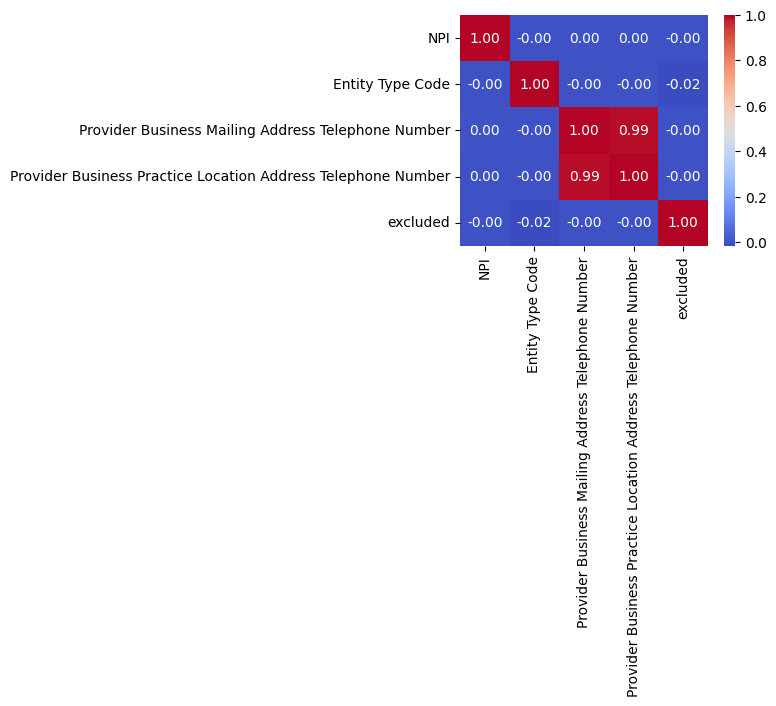

In [17]:
# Correlation heatmap — numeric columns
numeric_df = providers_df.select_dtypes(include='number')

plt.figure(figsize=(4, 3))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

### 5.2 RandomForest Feature Importance

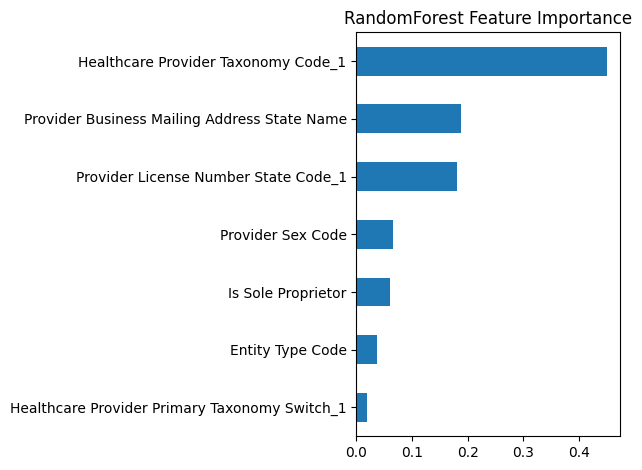

Healthcare Provider Taxonomy Code_1              0.450875
Provider Business Mailing Address State Name     0.187725
Provider License Number State Code_1             0.180989
Provider Sex Code                                0.064926
Is Sole Proprietor                               0.059861
Entity Type Code                                 0.036454
Healthcare Provider Primary Taxonomy Switch_1    0.019170
dtype: float64


In [18]:
# RandomForest feature importance — encode categoricals and rank by importance
categorical_feature_columns = [
    'Provider Business Mailing Address State Name',
    'Healthcare Provider Taxonomy Code_1',
    'Provider Sex Code',
    'Is Sole Proprietor',
    'Healthcare Provider Primary Taxonomy Switch_1',
    'Provider License Number State Code_1',
]
feature_importance_df = providers_df[['Entity Type Code'] + categorical_feature_columns + ['excluded']].copy()
feature_importance_df['Entity Type Code'] = feature_importance_df['Entity Type Code'].fillna(-1)
for column in categorical_feature_columns:
    feature_importance_df[column] = feature_importance_df[column].fillna('Unknown')

label_encoder = LabelEncoder()
for column in categorical_feature_columns:
    feature_importance_df[column] = label_encoder.fit_transform(feature_importance_df[column])

feature_columns = ['Entity Type Code'] + categorical_feature_columns
X = feature_importance_df[feature_columns]
y = feature_importance_df['excluded']

random_forest_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
random_forest_model.fit(X, y)

feature_importances = pd.Series(random_forest_model.feature_importances_, index=feature_columns)
feature_importances.sort_values(ascending=True).plot(kind='barh')
plt.title('RandomForest Feature Importance')
plt.tight_layout()
plt.show()

print(feature_importances.sort_values(ascending=False))

## 6. Summary

**Pitch:** Loaded 500K providers, stripped 305 sparse columns down to 26 usable ones, and found that exclusion risk is driven by specialty (pain/addiction medicine), geography (KY, ND, WV), and entity type (individuals vs organisations).

### Key findings
- Entity Type 1 (individual) has ~5x higher exclusion rate than Type 2 (organisation) — 0.254% vs 0.050%
- State is predictive — KY highest (0.55%), ~2x the national average (0.237%); rural states overrepresented; PR a notable outlier
- Taxonomy is the strongest signal — Pain/Addiction Medicine specialties top the list at 10x+ baseline

### Feature candidates for 03_modelling
- **Strong:** Healthcare Provider Taxonomy Code_1 · Provider Business Mailing Address State Name · Provider License Number State Code_1
- **Moderate:** Provider Sex Code · Is Sole Proprietor · Entity Type Code
- **Derive in 03:** Provider Enumeration Date → years_since_enumeration · Last Update Date → years_since_last_update · drop one of the two 0.99-correlated phone columns

### Known issues — fixed in 03_modelling
- Enumeration Date, Last Update Date → convert to datetime, extract year/month
- Entity Type Code → convert float to int/category